C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


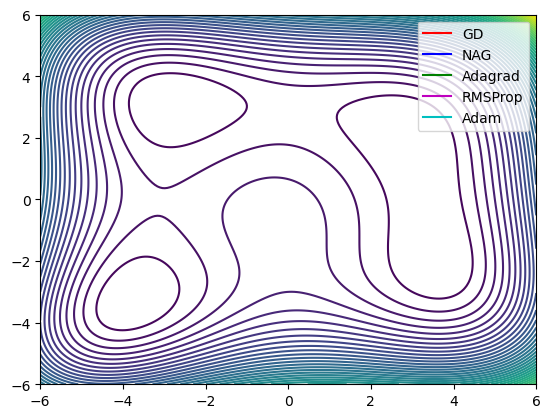

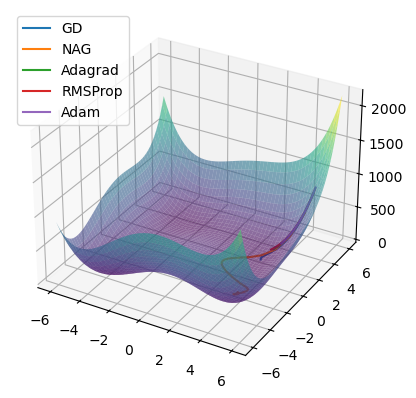

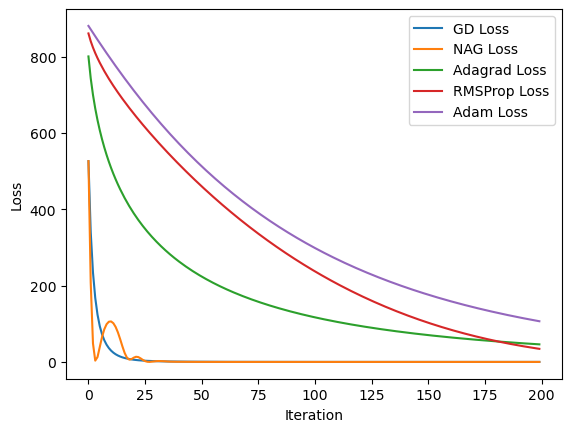

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Objective function and gradient
# -----------------------------
def f(w1, w2):
    return (w1**2 + w2 - 11)**2 + (w1 + w2**2 - 7)**2

def grad(w1, w2):
    df_dw1 = 2*(w1**2 + w2 - 11)*(2*w1) + 2*(w1 + w2**2 - 7)*1
    df_dw2 = 2*(w1**2 + w2 - 11)*1 + 2*(w1 + w2**2 - 7)*(2*w2)
    return np.array([df_dw1, df_dw2])

# -----------------------------
# Optimizers
# -----------------------------
def gradient_descent(w, lr=0.01, steps=100):
    history = []
    for i in range(steps):
        g = grad(w[0], w[1])
        w = w - lr*g
        history.append((w[0], w[1], f(w[0], w[1])))
    return np.array(history)

def nesterov(w, lr=0.01, momentum=0.9, steps=100):
    v = np.zeros_like(w)
    history = []
    for i in range(steps):
        g = grad(w[0]-momentum*v[0], w[1]-momentum*v[1])
        v = momentum*v + lr*g
        w = w - v
        history.append((w[0], w[1], f(w[0], w[1])))
    return np.array(history)

def adagrad(w, lr=0.1, steps=100, eps=1e-8):
    history = []
    G = np.zeros_like(w)
    for i in range(steps):
        g = grad(w[0], w[1])
        G += g**2
        w = w - (lr / (np.sqrt(G) + eps)) * g
        history.append((w[0], w[1], f(w[0], w[1])))
    return np.array(history)

def rmsprop(w, lr=0.01, steps=100, beta=0.9, eps=1e-8):
    history = []
    Eg = np.zeros_like(w)
    for i in range(steps):
        g = grad(w[0], w[1])
        Eg = beta*Eg + (1-beta)*(g**2)
        w = w - (lr / (np.sqrt(Eg) + eps)) * g
        history.append((w[0], w[1], f(w[0], w[1])))
    return np.array(history)

def adam(w, lr=0.01, steps=100, beta1=0.9, beta2=0.999, eps=1e-8):
    history = []
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    for t in range(1, steps+1):
        g = grad(w[0], w[1])
        m = beta1*m + (1-beta1)*g
        v = beta2*v + (1-beta2)*(g**2)
        m_hat = m / (1-beta1**t)
        v_hat = v / (1-beta2**t)
        w = w - lr*m_hat/(np.sqrt(v_hat)+eps)
        history.append((w[0], w[1], f(w[0], w[1])))
    return np.array(history)

# -----------------------------
# Run experiments
# -----------------------------
w0 = np.array([5.0, 5.0])  # initial point
gd_hist = gradient_descent(w0.copy(), lr=0.001, steps=200)
nag_hist = nesterov(w0.copy(), lr=0.001, steps=200)
adagrad_hist = adagrad(w0.copy(), lr=0.1, steps=200)
rmsprop_hist = rmsprop(w0.copy(), lr=0.01, steps=200)
adam_hist = adam(w0.copy(), lr=0.01, steps=200)

# -----------------------------
# Visualization: Contour + Trajectories
# -----------------------------
w1_vals = np.linspace(-6, 6, 200)
w2_vals = np.linspace(-6, 6, 200)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = f(W1, W2)

fig, ax = plt.subplots()
ax.contour(W1, W2, Z, levels=50)

lines = {
    "GD": ax.plot([], [], 'r-', label="GD")[0],
    "NAG": ax.plot([], [], 'b-', label="NAG")[0],
    "Adagrad": ax.plot([], [], 'g-', label="Adagrad")[0],
    "RMSProp": ax.plot([], [], 'm-', label="RMSProp")[0],
    "Adam": ax.plot([], [], 'c-', label="Adam")[0],
}
ax.legend()

histories = {
    "GD": gd_hist,
    "NAG": nag_hist,
    "Adagrad": adagrad_hist,
    "RMSProp": rmsprop_hist,
    "Adam": adam_hist,
}

def animate(i):
    for name, line in lines.items():
        line.set_data(histories[name][:i,0], histories[name][:i,1])
    return list(lines.values())

ani = animation.FuncAnimation(fig, animate, frames=len(gd_hist), interval=100)
plt.show()

# -----------------------------
# Visualization: 3D Surface
# -----------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6)

for name, hist in histories.items():
    ax.plot(hist[:,0], hist[:,1], hist[:,2], label=name)

ax.legend()
plt.show()

# -----------------------------
# Loss vs Iteration
# -----------------------------
plt.figure()
for name, hist in histories.items():
    plt.plot(hist[:,2], label=f"{name} Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()


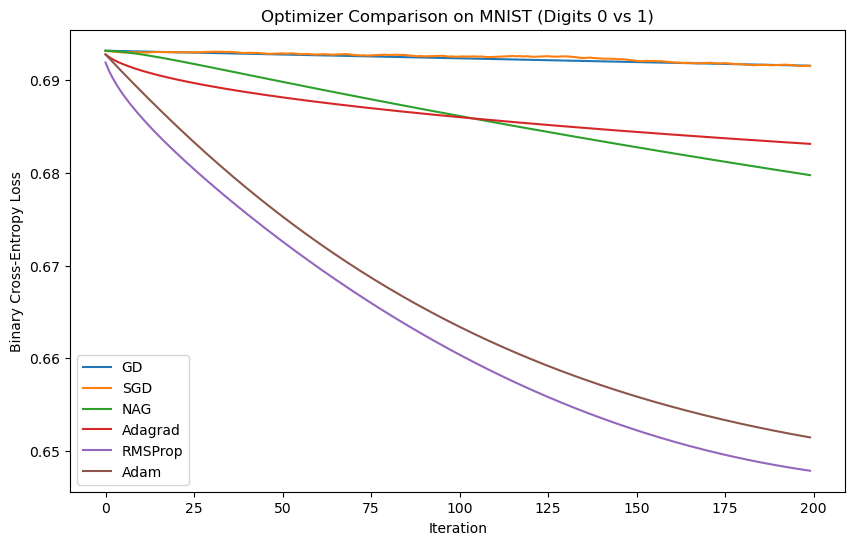

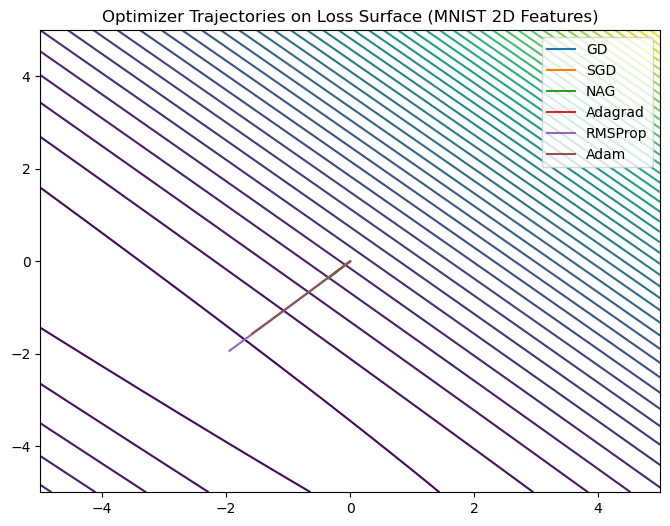

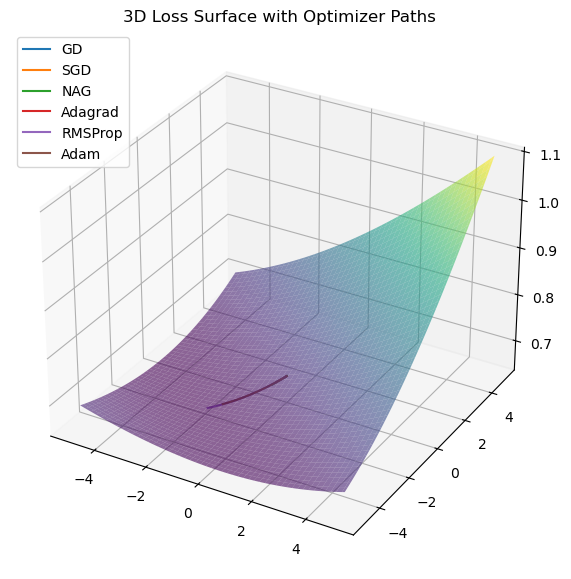

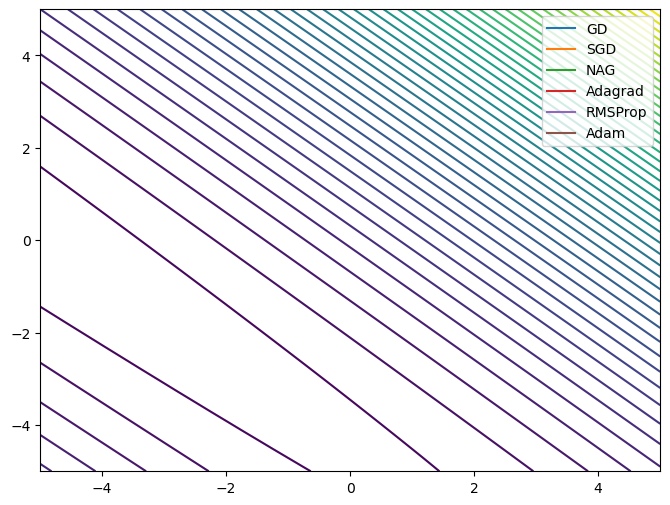

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Load MNIST dataset
# -----------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and flatten images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# Use only digits 0 and 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

# Reduce to two features: average intensity left vs right half
feature1 = x_train[:, :392].mean(axis=1)
feature2 = x_train[:, 392:].mean(axis=1)
X_train = np.column_stack([feature1[train_mask], feature2[train_mask]])
y_train_bin = y_train[train_mask]

feature1_test = x_test[:, :392].mean(axis=1)
feature2_test = x_test[:, 392:].mean(axis=1)
X_test = np.column_stack([feature1_test[test_mask], feature2_test[test_mask]])
y_test_bin = y_test[test_mask]

# -----------------------------
# Logistic Regression Model
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict(X, w):
    return sigmoid(np.dot(X, w))

def loss(X, y, w):
    y_pred = predict(X, w)
    return -np.mean(y*np.log(y_pred+1e-8) + (1-y)*np.log(1-y_pred+1e-8))

def gradient(X, y, w):
    y_pred = predict(X, w)
    return np.dot(X.T, (y_pred - y)) / X.shape[0]

# -----------------------------
# Optimizers
# -----------------------------
def run_optimizer(X, y, optimizer, steps=100, lr=0.01):
    w = np.zeros(X.shape[1])
    history = []
    if optimizer == "GD":
        for i in range(steps):
            g = gradient(X, y, w)
            w -= lr * g
            history.append((w[0], w[1], loss(X, y, w)))
    elif optimizer == "SGD":
        for i in range(steps):
            idx = np.random.randint(0, X.shape[0])
            g = gradient(X[idx:idx+1], y[idx:idx+1], w)
            w -= lr * g
            history.append((w[0], w[1], loss(X, y, w)))
    elif optimizer == "NAG":
        v = np.zeros_like(w)
        momentum = 0.9
        for i in range(steps):
            g = gradient(X, y, w - momentum*v)
            v = momentum*v + lr*g
            w -= v
            history.append((w[0], w[1], loss(X, y, w)))
    elif optimizer == "Adagrad":
        G = np.zeros_like(w)
        eps = 1e-8
        for i in range(steps):
            g = gradient(X, y, w)
            G += g**2
            w -= (lr / (np.sqrt(G)+eps)) * g
            history.append((w[0], w[1], loss(X, y, w)))
    elif optimizer == "RMSProp":
        Eg = np.zeros_like(w)
        beta = 0.9
        eps = 1e-8
        for i in range(steps):
            g = gradient(X, y, w)
            Eg = beta*Eg + (1-beta)*(g**2)
            w -= (lr / (np.sqrt(Eg)+eps)) * g
            history.append((w[0], w[1], loss(X, y, w)))
    elif optimizer == "Adam":
        m = np.zeros_like(w)
        v = np.zeros_like(w)
        beta1, beta2 = 0.9, 0.999
        eps = 1e-8
        for t in range(1, steps+1):
            g = gradient(X, y, w)
            m = beta1*m + (1-beta1)*g
            v = beta2*v + (1-beta2)*(g**2)
            m_hat = m / (1-beta1**t)
            v_hat = v / (1-beta2**t)
            w -= lr*m_hat/(np.sqrt(v_hat)+eps)
            history.append((w[0], w[1], loss(X, y, w)))
    return np.array(history)

# -----------------------------
# Run Experiments
# -----------------------------
optimizers = ["GD", "SGD", "NAG", "Adagrad", "RMSProp", "Adam"]
histories = {}
for opt in optimizers:
    histories[opt] = run_optimizer(X_train, y_train_bin, opt, steps=200, lr=0.01)

# -----------------------------
# Loss vs Iteration
# -----------------------------
plt.figure(figsize=(10,6))
for opt in optimizers:
    plt.plot(histories[opt][:,2], label=opt)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Optimizer Comparison on MNIST (Digits 0 vs 1)")
plt.legend()
plt.show()

# -----------------------------
# 2D Contour Plot with Trajectories
# -----------------------------
w1_vals = np.linspace(-5, 5, 100)
w2_vals = np.linspace(-5, 5, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i,j], W2[i,j]])
        Z[i,j] = loss(X_train, y_train_bin, w)

fig, ax = plt.subplots(figsize=(8,6))
ax.contour(W1, W2, Z, levels=50)
for opt in optimizers:
    traj = histories[opt]
    ax.plot(traj[:,0], traj[:,1], label=opt)
ax.legend()
plt.title("Optimizer Trajectories on Loss Surface (MNIST 2D Features)")
plt.show()

# -----------------------------
# 3D Surface Plot with Trajectories
# -----------------------------
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6)
for opt in optimizers:
    traj = histories[opt]
    ax.plot(traj[:,0], traj[:,1], traj[:,2], label=opt)
ax.legend()
plt.title("3D Loss Surface with Optimizer Paths")
plt.show()

# -----------------------------
# Animation (2D Contour)
# -----------------------------
fig, ax = plt.subplots(figsize=(8,6))
ax.contour(W1, W2, Z, levels=50)
lines = {opt: ax.plot([], [], label=opt)[0] for opt in optimizers}
ax.legend()

def animate(i):
    for opt in optimizers:
        lines[opt].set_data(histories[opt][:i,0], histories[opt][:i,1])
    return list(lines.values())

ani = animation.FuncAnimation(fig, animate, frames=200, interval=100)
plt.show()


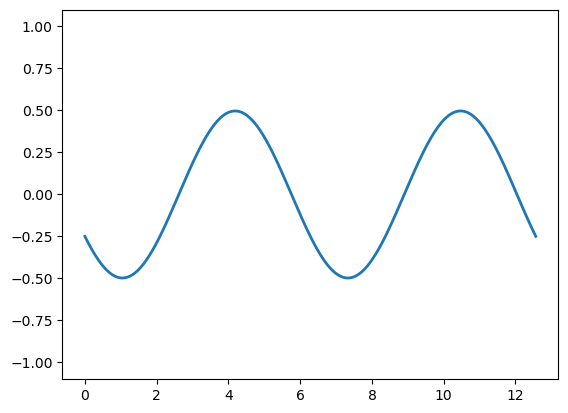

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Set up the figure
fig, ax = plt.subplots()
x = np.linspace(0, 4*np.pi, 400)

line, = ax.plot(x, np.sin(x), lw=2)

def update(frame):
    y = np.sin(x + 0.05*frame) * np.cos(0.1*frame)
    line.set_ydata(y)
    return line,

ani = animation.FuncAnimation(
    fig, update, frames=200, interval=50, blit=True
)

# This is the key line for Jupyter:
HTML(ani.to_jshtml())
